In [3]:
# Load data

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('ebike-stopping-distances.csv')
df

,speed,distance
0,15.4,3.6
1,16.2,3.8
2,17.2,4.3
3,19.4,5.1
4,25.7,7.6
5,26.8,8.5
6,32.6,9.9
7,34.7,11.9
8,36.3,14.2


Text(0, 0.5, 'Stopping Distance (m)')

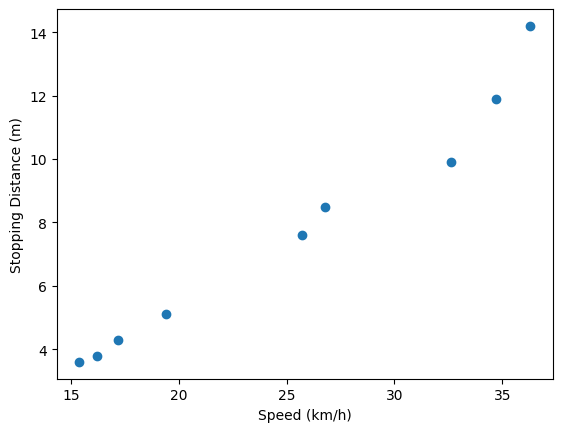

In [4]:
# Visualize data

plt.scatter(df['speed'], df['distance'])
plt.xlabel('Speed (km/h)')
plt.ylabel('Stopping Distance (m)')

In [5]:
# MODELING THE RELATIONSHIP WITH PYTHON CLASS USING SCIKIT-LEARN LIBRARY

import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

class LinearModel:
    def __init__(self, model_name=""):
        self.model_name = model_name
        
    def fit(self, x, y):
        x = pd.DataFrame(x)
        linear_model = LinearRegression().fit(x, y)
        y_pred = linear_model.predict(x)
        self.slope = linear_model.coef_[0]
        self.intercept = linear_model.intercept_
        self.rsquared = r2_score(y, y_pred)
        
    def predict(self, x):
        return self.slope * x + self.intercept

    def plot_model(self, x_min, x_max, color="black"):
        y_min = self.predict(x_min)
        y_max = self.predict(x_max)
        plt.plot([x_min, x_max], [y_min, y_max], color=color)
        
    def print_model_info(self):
        m = self.slope
        b = self.intercept
        rsquared = self.rsquared
        model_name = self.model_name
        print(f'LinearModel({model_name}):')
        print(f'Parameters: slope = {m:.2f}, intercept = {b:.2f}')
        print(f'Equation: y = {m:.2f}x + {b:.2f}')
        print(f'Goodness of Fit (R²): {rsquared:.3f}')

In [ ]:
# Create and fit a new LinearModel to the speed and distance data

linear = LinearModel()
linear.fit(x=df['speed'], y=df['distance'])
linear.print_model_info()                   #print model info

LinearModel():
Parameters: slope = 0.45, intercept = -3.64
Equation: y = 0.45x + -3.64
Goodness of Fit (R²): 0.968


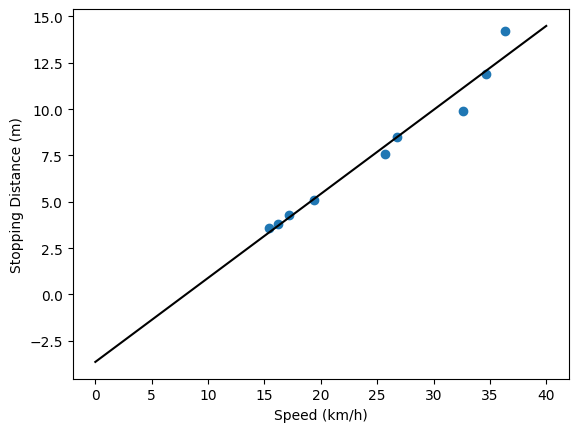

In [10]:
# Plot linear model from 0 to 40 km/h

plt.scatter(df['speed'], df['distance'])
plt.xlabel('Speed (km/h)')
plt.ylabel('Stopping Distance (m)')
linear.plot_model(0, 40)

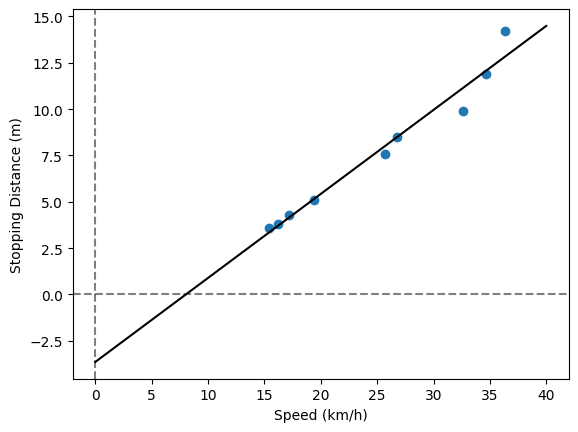

In [11]:
# Add horizontal an vertical axis lines

plt.scatter(df['speed'], df['distance'])
plt.xlabel('Speed (km/h)')
plt.ylabel('Stopping Distance (m)')
linear.plot_model(0, 40)
plt.axhline(color='black', alpha=0.5, linestyle='--')
plt.axvline(color='black', alpha=0.5, linestyle='--')

In [12]:
# Load low speed data

df_low = pd.read_csv('ebike-data-low-speed.csv')
df_low

,speed,distance
0,0.0,0.00
1,2.0,0.04
2,3.0,0.10
3,5.0,0.20
4,7.0,0.33
5,8.0,0.86
6,10.0,1.50
7,11.0,1.79
8,13.0,2.26


In [13]:
# Define a reuseable function to label and format axes

def format_axes():
    plt.xlabel('Speed (km/h)')
    plt.ylabel('Stopping Distance (m)')
    plt.axhline(color='black', alpha=0.5, linestyle='--')
    plt.axvline(color='black', alpha=0.5, linestyle='--')

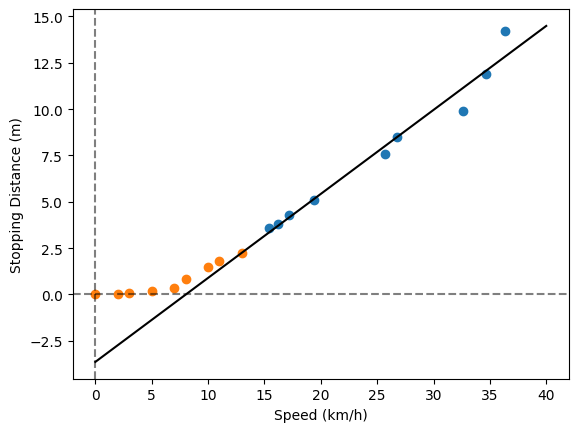

In [14]:
# Plotting multiple graphs using C0 color for original and C1 color for the low_speed data
# Plot model from 0 to 40 km/h

plt.scatter(df['speed'], df['distance'], color='C0')
plt.scatter(df_low['speed'], df_low['distance'], color='C1')
linear.plot_model(0, 40)
format_axes()

In [15]:
# QUADRATIC MODEL: A QUADRATIC CURVE IS USED WHEN MODELING A MODERATE AMOUNT OF CURVATURE
# A quadratic equation is a second-degree POLYNOMIAL of the form: y = ax² + bx + c
# The equation for Kinetics energy from physics (KE = 1/2mv²) is also quadratic
# Since stopping needs to overcome kinetic energy, a quadratic model is a natural choice

# QUADRATIC MODEL PYTHON CLASS

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

class QuadraticModel:
    def fit(self, x, y):
        x = pd.DataFrame(x)
        quadratic = PolynomialFeatures(degree=2)
        quad_features = quadratic.fit_transform(x)
        quad_model = LinearRegression().fit(quad_features, y)
        y_pred = quad_model.predict(quad_features)
        self.a = quad_model.coef_[2]
        self.b = quad_model.coef_[1]
        self.c = quad_model.intercept_
        self.rsquared = r2_score(y, y_pred)
        
    def predict(self, x):
        return self.a*x**2 + self.b*x + self.c
       
    def plot_model(self, xmin, xmax):
        xvals = range(xmin, xmax+1)
        yvals = [self.predict(x) for x in xvals]
        plt.plot(xvals, yvals, color='black')
        
    def print_model_info(self):
        a = self.a
        b = self.b
        c = self.c
        rsquared = self.rsquared
        print('QuadraticModel')
        print(f'Parameters: a = {a:.2f}, b = {b:.2f}, c = {c:.2f}')
        print(f'Equation: y = {self.a:.2f}x² + {self.b:.2f}x + {self.c:.2f}')
        print(f'Goodness of Fit (R²): {rsquared:.3f}')

In [16]:
# Using pandas pd.concat() method, combine both df and df_low to a single DataFrame

df_all = pd.concat([df, df_low])
quadratic = QuadraticModel()                             #initiate new QuadraticModel
quadratic.fit(df_all['speed'], df_all['distance'])       #fit model
quadratic.print_model_info()                             #print model info

QuadraticModel
Parameters: a = 0.01, b = 0.14, c = -0.43
Equation: y = 0.01x² + 0.14x + -0.43
Goodness of Fit (R²): 0.989


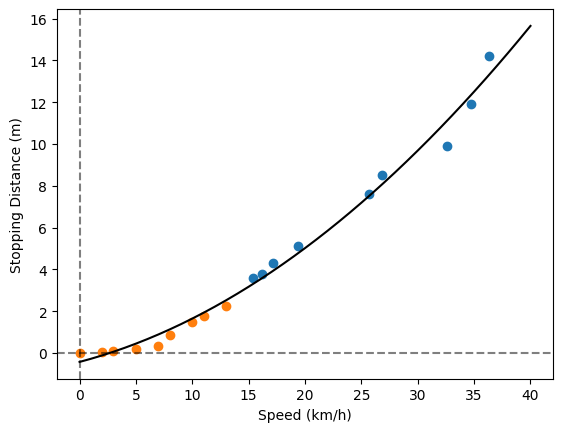

In [17]:
# Plot the quadratic model

plt.scatter(df['speed'], df['distance'], color='C0')
plt.scatter(df_low['speed'], df_low['distance'], color='C1')
quadratic.plot_model(0, 40)
format_axes()

In [18]:
# Load high speed data

df_high = pd.read_csv('ebike-data-high-speed.csv')
df_high

,speed,distance
0,38,14.35
1,39,15.09
2,42,17.74
3,42,15.75
4,42,17.61
5,43,18.38
6,47,20.36
7,52,26.58
8,52,24.53
9,55,24.71


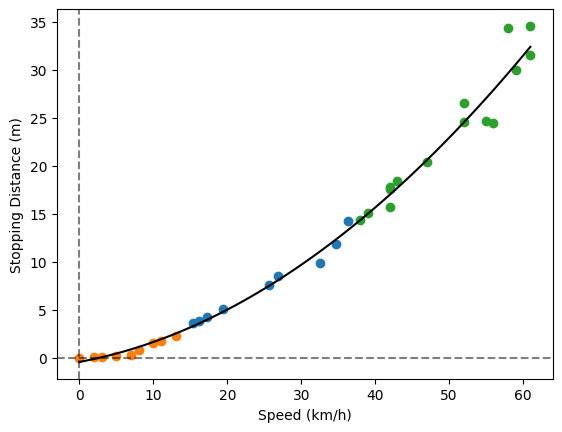

In [20]:
# See how the quadratic model can predict this new data it wasn't trained on
# Plot the high speed data in 'C2' color

plt.scatter(df['speed'], df['distance'], color='C0')
plt.scatter(df_low['speed'], df_low['distance'], color='C1')
plt.scatter(df_high['speed'], df_high['distance'], color='C2')
quadratic.plot_model(0, 61)
format_axes()